# Banking Marketing Campaign

## Business Insight

Long-term deposits allow banks to keep customer money for a fixed period, which helps the bank use that capital for investments. These products are usually promoted through phone marketing campaigns. If a customer is not available during one call, the bank may try again later.

The bank is facing a decline in revenue and wants to identify which existing customers are more likely to subscribe to a long-term deposit. This would help the bank focus its marketing efforts on high-potential customers and reduce time and cost spent on customers who are unlikely to convert.

The goal of this project is to build a ranking or prediction model that estimates whether a customer will subscribe to a long-term deposit.

## Project Steps

### Step 1: Load the dataset

The dataset is available in the project folder as:

`bank-marketing-campaign-data.csv`

It can also be loaded from:

`https://breathecode.herokuapp.com/asset/internal-link?id=413&path=bank-marketing-campaign-data.csv`

The dataset contains customer information, campaign information, and macroeconomic indicators, as well as the target variable:

- `y`: whether the customer subscribed to a long-term deposit

### Step 2: Perform a full EDA

This step is necessary to understand the data and decide which variables are useful for the model.

Main tasks:
- inspect the dataset
- check data types
- detect missing values
- review duplicated rows
- analyze categorical and numerical variables
- explore the target distribution
- study correlations
- remove irrelevant or problematic columns if needed
- prepare the data for modeling

The dataset should also be split into:
- training set
- testing set

### Step 3: Build a logistic regression model

Create a first logistic regression model using the default configuration, after preprocessing the data correctly.

### Step 4: Optimize the model

If the baseline model is not good enough, improve it using one of the techniques seen in class, such as:
- class balancing
- changing `C`
- trying different solvers
- adjusting `max_iter`

The final goal is to obtain a model that predicts customer subscription as accurately as possible.

In [2]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_auc_score,
    RocCurveDisplay
)

## Load the dataset

In [3]:
url = "https://breathecode.herokuapp.com/asset/internal-link?id=413&path=bank-marketing-campaign-data.csv"
df = pd.read_csv(url, sep=";")

df.head()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


## Conclusion
The dataset was loaded successfully using `sep=";"`, which is necessary because the file is separated by semicolons instead of commas.

## Basic inspection
We check the size of the dataset, the column names, and the data types.

In [4]:
print("Shape of the dataset:", df.shape)
print("\nColumns:")
print(df.columns)

print("\nData types:")
print(df.dtypes)

Shape of the dataset: (41188, 21)

Columns:
Index(['age', 'job', 'marital', 'education', 'default', 'housing', 'loan',
       'contact', 'month', 'day_of_week', 'duration', 'campaign', 'pdays',
       'previous', 'poutcome', 'emp.var.rate', 'cons.price.idx',
       'cons.conf.idx', 'euribor3m', 'nr.employed', 'y'],
      dtype='str')

Data types:
age                 int64
job                   str
marital               str
education             str
default               str
housing               str
loan                  str
contact               str
month                 str
day_of_week           str
duration            int64
campaign            int64
pdays               int64
previous            int64
poutcome              str
emp.var.rate      float64
cons.price.idx    float64
cons.conf.idx     float64
euribor3m         float64
nr.employed       float64
y                     str
dtype: object


## Conclusion
The dataset contains customer information, campaign details, and economic indicators.

We can also see that:
- some columns are numerical
- some columns are categorical
- the target column `y` is categorical and will need to be converted to numeric later

## Check Missing Values and Duplicates

### Objective
Review the quality of the dataset before analysis.

### Why this step matters
Missing values and duplicated rows can affect both the exploratory analysis and the model performance.

In [5]:
print("Missing values by column:")
print(df.isnull().sum())

print("\nDuplicated rows:")
print(df.duplicated().sum())

Missing values by column:
age               0
job               0
marital           0
education         0
default           0
housing           0
loan              0
contact           0
month             0
day_of_week       0
duration          0
campaign          0
pdays             0
previous          0
poutcome          0
emp.var.rate      0
cons.price.idx    0
cons.conf.idx     0
euribor3m         0
nr.employed       0
y                 0
dtype: int64

Duplicated rows:
12


In [6]:
# Remove duplicated rows
df = df.drop_duplicates().reset_index(drop=True)

print("Shape after removing duplicates:")
print(df.shape)

Shape after removing duplicates:
(41176, 21)


## Conclusion
This step confirms whether the dataset needs cleaning.

Duplicated rows were removed to avoid repeating the same observations in the model. If the dataset has no missing values, we can continue without extra imputation.

## Statistical Summary

### Objective
Review the main statistics of the dataset.

### Why this step matters
This helps us better understand the distribution of numerical variables and the frequency of categorical variables.

In [7]:
# Summary of numerical columns
df.describe()

,age,duration,campaign,pdays,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed
count,41176.00000,41176.000000,41176.000000,41176.000000,41176.000000,41176.000000,41176.000000,41176.000000,41176.000000,41176.000000
mean,40.02380,258.315815,2.567879,962.464810,0.173013,0.081922,93.575720,-40.502863,3.621293,5167.034870
std,10.42068,259.305321,2.770318,186.937102,0.494964,1.570883,0.578839,4.627860,1.734437,72.251364
min,17.00000,0.000000,1.000000,0.000000,0.000000,-3.400000,92.201000,-50.800000,0.634000,4963.600000
25%,32.00000,102.000000,1.000000,999.000000,0.000000,-1.800000,93.075000,-42.700000,1.344000,5099.100000
50%,38.00000,180.000000,2.000000,999.000000,0.000000,1.100000,93.749000,-41.800000,4.857000,5191.000000
75%,47.00000,319.000000,3.000000,999.000000,0.000000,1.400000,93.994000,-36.400000,4.961000,5228.100000
max,98.00000,4918.000000,56.000000,999.000000,7.000000,1.400000,94.767000,-26.900000,5.045000,5228.100000


In [8]:
# Summary of categorical columns
df.describe(include="object")

'''In pandas, "object" usually means text data, 
so in the dataset it normally refers to string or categorical-like columns.'''

/tmp/ipykernel_23209/1780551847.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df.describe(include="object")


'In pandas, "object" usually means text data, \nso in the dataset it normally refers to string or categorical-like columns.'

## Conclusion
The numerical summary helps to understand the scale, range, and possible outliers of the quantitative variables.

The categorical summary helps to identify:
- the number of unique categories
- the most frequent category
- whether some categories dominate the data

## Analyze the Target Variable

### Objective
Inspect the distribution of the target column `y`.

In [9]:
print(df["y"].value_counts())

print("\nProportion of each class:")
print(df["y"].value_counts(normalize=True))

y
no     36537
yes     4639
Name: count, dtype: int64

Proportion of each class:
y
no     0.887337
yes    0.112663
Name: proportion, dtype: float64


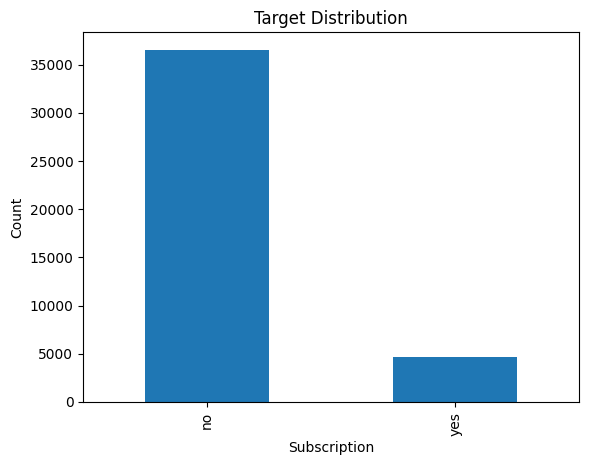

In [10]:
df["y"].value_counts().plot(kind="bar")
plt.title("Target Distribution")
plt.xlabel("Subscription")
plt.ylabel("Count")
plt.show()

## Conclusion
The target distribution shows whether the marketing outcome is balanced or not. In this case, there is a big distribution difference between "no" and "yes". 

## Convert the Target Variable

### Objective
Transform the target into numeric values.

In [11]:
df["y"] = df["y"].map({"yes": 1, "no": 0})

df["y"].value_counts()

y
0    36537
1     4639
Name: count, dtype: int64

### Conclusion
The target column has been converted successfully:
- `yes` becomes `1`
- `no` becomes `0`

## Separate Numerical and Categorical Columns

### Objective
Identify which columns are numerical and which are categorical.

In [12]:
categorical_columns = df.select_dtypes(include=["object"]).columns.tolist()
numerical_columns = df.select_dtypes(include=["int64", "float64"]).columns.tolist()

# Remove target from numerical columns
if "y" in numerical_columns:
    numerical_columns.remove("y")

print("Categorical columns:")
print(categorical_columns)

print("\nNumerical columns:")
print(numerical_columns)

Categorical columns:
['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'day_of_week', 'poutcome']

Numerical columns:
['age', 'duration', 'campaign', 'pdays', 'previous', 'emp.var.rate', 'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed']


/tmp/ipykernel_23209/2629170646.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_columns = df.select_dtypes(include=["object"]).columns.tolist()


## Explore Categorical Variables

In [13]:
for col in categorical_columns:
    print(f"\nValue counts for {col}:")
    print(df[col].value_counts())


Value counts for job:
job
admin.           10419
blue-collar       9253
technician        6739
services          3967
management        2924
retired           1718
entrepreneur      1456
self-employed     1421
housemaid         1060
unemployed        1014
student            875
unknown            330
Name: count, dtype: int64

Value counts for marital:
marital
married     24921
single      11564
divorced     4611
unknown        80
Name: count, dtype: int64

Value counts for education:
education
university.degree      12164
high.school             9512
basic.9y                6045
professional.course     5240
basic.4y                4176
basic.6y                2291
unknown                 1730
illiterate                18
Name: count, dtype: int64

Value counts for default:
default
no         32577
unknown     8596
yes            3
Name: count, dtype: int64

Value counts for housing:
housing
yes        21571
no         18615
unknown      990
Name: count, dtype: int64

Value counts for

## Explore Numerical Variables

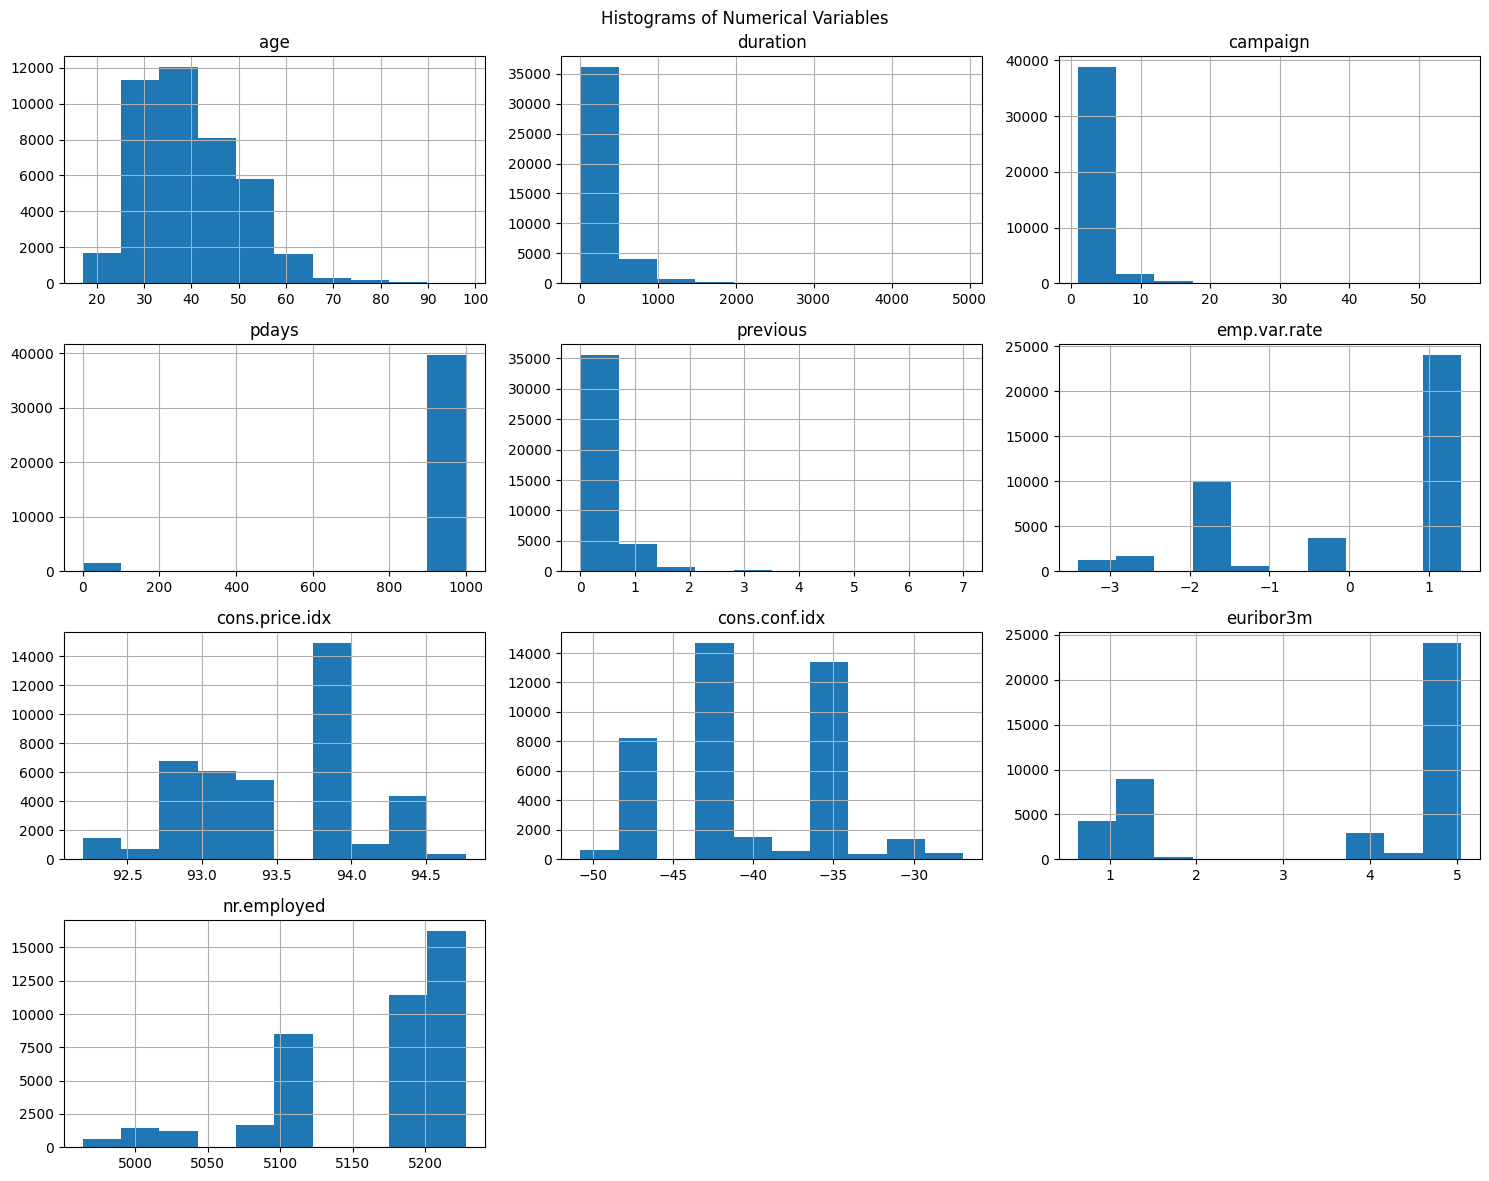

In [14]:
df[numerical_columns].hist(figsize=(15, 12))
plt.suptitle("Histograms of Numerical Variables")
plt.tight_layout()
plt.show()

## Conclusion

The histograms show that the numerical variables have very different distributions.

Main observations:
- `age` looks moderately spread, with most customers concentrated in adult age ranges, and a slight right tail.
- `duration`, `campaign`, and `previous` are strongly right-skewed, meaning most customers have low values and a small number have very high values.
- `pdays` is highly concentrated around one very large value, which suggests a special coded value rather than a naturally continuous distribution.
- `emp.var.rate`, `cons.price.idx`, `cons.conf.idx`, `euribor3m`, and `nr.employed` appear to have grouped or repeated values, which is reasonable because they are macroeconomic indicators observed at specific time periods rather than purely continuous individual measurements.

Overall, the numerical variables are not normally distributed, and several of them show clear skewness or concentration patterns.  
Because of this, scaling the numerical features is important before training the logistic regression model.

## Correlation Analysis

In [15]:
correlation_matrix = df[numerical_columns + ["y"]].corr() #all numerical columns, and also the target column y
                                                          #Because .corr() only works with numeric data, we add y after converting it to 0 and 1 so we can measure how each numerical feature relates to the target.

print(correlation_matrix["y"].sort_values(ascending=False))

y                 1.000000
duration          0.405297
previous          0.230202
cons.conf.idx     0.054802
age               0.030381
campaign         -0.066361
cons.price.idx   -0.136134
emp.var.rate     -0.298289
euribor3m        -0.307740
pdays            -0.324948
nr.employed      -0.354669
Name: y, dtype: float64


# Conclusion
From the correlation analysis, the variables most positively associated with subscription are:
- `duration` (`0.405`)
- `previous` (`0.230`)

This suggests that longer calls and more previous contacts are associated with a higher probability of subscription.

The variables most negatively associated with subscription are:
- `nr.employed` (`-0.355`)
- `pdays` (`-0.325`)
- `euribor3m` (`-0.308`)
- `emp.var.rate` (`-0.298`)

This suggests that some economic indicators and contact history variables may be important predictors of customer behavior.

## Define Features and Target
- `X` for the input variables
- `y` for the target variable

In [16]:
X = df.drop("y", axis=1)
y = df["y"]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (41176, 20)
y shape: (41176,)


## Train-Test Split

In [17]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y #means that the train set and the test set will keep a similar proportion of the target classes as the original dataset
)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (32940, 20)
X_test shape: (8236, 20)
y_train shape: (32940,)
y_test shape: (8236,)


## Preprocessing
### Objective
- scale the numerical variables

- encode the categorical variables

- combine both results into one processed dataset ready for the model

In [ ]:
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numerical_columns), #applies standardization to all numerical columns
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_columns) #converts all categorical columns into numeric format and ignores unseen categories if they appear later
    ]
)

## Build the Baseline Logistic Regression Model

In [19]:
baseline_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", LogisticRegression(max_iter=1000))
])

baseline_model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers co

### Explanation of the code

`Pipeline(steps=[...])`  
creates a sequence of steps that will be applied in order.

Inside the pipeline:

- `("preprocessor", preprocessor)`  
  applies the preprocessing object created in the previous step  
  This means:
  - numerical columns are scaled
  - categorical columns are one-hot encoded

- `("model", LogisticRegression(max_iter=1000))`  
  creates a logistic regression model

### Why do we use `max_iter=1000`?

Logistic regression trains through an optimization process that may need several iterations to converge.

`max_iter=1000` gives the model enough iterations to finish training properly and helps avoid convergence warnings.

### What does `.fit(X_train, y_train)` do?

This line trains the pipeline on the training data.

When we call:

`baseline_model.fit(X_train, y_train)`

the pipeline does two things automatically:

1. preprocesses `X_train`
2. trains the logistic regression model using `y_train` as the target

## Evaluate the Baseline Model

### Objective
Measure the performance of the first model.

In [20]:
y_pred = baseline_model.predict(X_test) #generates the predicted class for each row in X_test
y_pred_proba = baseline_model.predict_proba(X_test)[:, 1] #generates the predicted probabilities instead of the final class labels.

print("Accuracy:", accuracy_score(y_test, y_pred))
print("ROC AUC:", roc_auc_score(y_test, y_pred_proba)) #roc_auc_score is a metric that measures how well the model separates the two classes.

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

Accuracy: 0.9095434677027683
ROC AUC: 0.938979837872525

Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.97      0.95      7308
           1       0.65      0.42      0.51       928

    accuracy                           0.91      8236
   macro avg       0.79      0.70      0.73      8236
weighted avg       0.90      0.91      0.90      8236


Confusion Matrix:
[[7099  209]
 [ 536  392]]


### How to read the confusion matrix

The confusion matrix is organized as:

- rows = actual classes
- columns = predicted classes

In this project:
- `0` = non-subscriber
- `1` = subscriber

So the confusion matrix confirms this:
- `7099` non-subscribers were correctly classified
- `392` subscribers were correctly classified
- `536` actual subscribers were missed
- `209` non-subscribers were incorrectly predicted as subscribers

| Actual \ Predicted | Predicted 0 | Predicted 1 |
|--------------------|-------------|-------------|
| Actual 0 (No)      | 7099        | 209         |
| Actual 1 (Yes)     | 536         | 392         |

## Optimize the Model

### Objective
Improve the baseline model using GridSearchCV.

In [21]:
param_grid = {
    "model__C": [0.01, 0.1, 1, 10],
    "model__solver": ["liblinear", "lbfgs"],
    "model__class_weight": [None, "balanced"]
} #defines the hyperparameter values that will be tested

optimized_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", LogisticRegression(max_iter=2000))
])

grid_search = GridSearchCV(
    optimized_model,
    param_grid,
    cv=5,
    scoring="roc_auc",
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step..._iter=2000))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'model__C': [0.01, 0.1, ...], 'model__class_weight': [None, 'balanced'], 'model__solver': ['liblinear', 'lbfgs']}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'roc_auc'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter can

### Code explanation

#### `param_grid = {...}`

This dictionary defines the hyperparameter values that will be tested.

- `"model__C": [0.01, 0.1, 1, 10]`  
  Tests different values of `C`, which controls the strength of regularization in logistic regression.  
  - smaller `C` = stronger regularization  
  - larger `C` = weaker regularization  

> The values `[0.01, 0.1, 1, 10]` are candidate hyperparameter values used to test different levels of regularization strength in logistic regression.

They are chosen to cover a broad range:

- `0.01` = strong regularization
- `0.1` = moderately strong regularization
- `1` = standard baseline value
- `10` = weaker regularization

These values are commonly selected in powers of 10 so that the model can be tested across different scales in a simple and efficient way.

- `"model__solver": ["liblinear", "lbfgs"]`  
  Tests two different optimization algorithms used to train logistic regression.

- `"model__class_weight": [None, "balanced"]`  
  Tests whether the model should use the normal class weights or automatically balance them.  
  This is useful because the target variable is imbalanced.

#### `optimized_model = Pipeline(...)`

This creates a new pipeline, similar to the baseline model.

It includes:
- the same preprocessing step
- a logistic regression model

This pipeline will be used inside `GridSearchCV` to test multiple combinations of parameters.

#### `LogisticRegression(max_iter=2000)`

This creates the logistic regression model for tuning.

`max_iter=2000` gives the model more iterations so it has enough time to converge while testing different parameter combinations.

#### `grid_search = GridSearchCV(...)`

This creates the object that will search for the best model.

- `optimized_model`  
  is the pipeline that will be trained repeatedly

- `param_grid`  
  tells GridSearchCV which parameter combinations to test

- `cv=5`  
  means 5-fold cross-validation  
  The training data is split into 5 parts, and the model is trained and validated 5 times

- `scoring="roc_auc"`  
  tells GridSearchCV to choose the best model based on ROC AUC

- `n_jobs=-1`  
  means use all available CPU cores to speed up the process

#### `grid_search.fit(X_train, y_train)`

This line starts the optimization process.

For each hyperparameter combination, GridSearchCV:
1. preprocesses the training data
2. trains the model
3. evaluates it with 5-fold cross-validation
4. stores the performance

At the end, it keeps the best combination according to ROC AUC.

#### Why do we use `model__` in the parameter names?

Because the logistic regression model is inside a pipeline step called `"model"`.

So:
- `"model__C"` means the parameter `C` inside the `model` step
- `"model__solver"` means the parameter `solver` inside the `model` step
- `"model__class_weight"` means the parameter `class_weight` inside the `model` step

## Evaluate the Optimized Model

### Objective
Measure the performance of the tuned model.

In [22]:
best_model = grid_search.best_estimator_

y_pred_best = best_model.predict(X_test)
y_pred_proba_best = best_model.predict_proba(X_test)[:, 1]

print("Accuracy:", accuracy_score(y_test, y_pred_best))
print("ROC AUC:", roc_auc_score(y_test, y_pred_proba_best))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_best))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_best))

Accuracy: 0.8642544924720739
ROC AUC: 0.9402760968140724

Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.86      0.92      7308
           1       0.45      0.91      0.60       928

    accuracy                           0.86      8236
   macro avg       0.72      0.88      0.76      8236
weighted avg       0.93      0.86      0.88      8236


Confusion Matrix:
[[6275 1033]
 [  85  843]]


## Final Model Conclusion

The optimized logistic regression model improves the bank’s ability to detect customers who are likely to subscribe to a long-term deposit.

Compared with the baseline model, the overall accuracy decreases from about `0.91` to `0.86`, but the model becomes much better at identifying the positive class (`yes`). In particular, the recall for subscribers increases strongly from `0.42` to `0.91`. This means the optimized model now captures most of the actual subscribers, which is very valuable for the business objective.

The ROC AUC also improves slightly, reaching `0.94`, which shows that the model has an excellent ability to separate likely subscribers from non-subscribers.

From the confusion matrix:
- `6275` non-subscribers were correctly classified
- `843` subscribers were correctly classified
- only `85` subscribers were missed
- `1033` non-subscribers were incorrectly predicted as subscribers

This means the optimized model is much more aggressive in identifying potential subscribers. As a result, it finds far more true subscribers, but it also increases the number of false positives.

Overall, this is a good trade-off for the business problem. Since the main goal of the campaign is to identify as many likely subscribers as possible, improving recall for class `1` is more important than maximizing accuracy alone. Therefore, the optimized model is more useful than the baseline model for supporting marketing decisions.